# Keithley DMM7510 DCV offset measurement demo

This notebook measures the amplified DUT offset at the DMM input and reports the equivalent input offset after division by the closed-loop gain of 1001. The expected DMM input is within about 1 mV.

Recommended setup:

- Connect the DMM7510 rear USB Type-B device port to the PC.
- Connect DUT output to DMM INPUT HI/LO. Keep the cabling shielded and avoid ground loops.
- Warm up both the DMM and DUT. Keithley specifies at least 90 minutes for rated DMM accuracy.
- Do not enable REL/null while measuring DUT offset; it would subtract the quantity being measured.
- This demo uses Auto Zero, a fixed 100 mV range, high input impedance, and 10 NPLC. It preserves individual readings and averages them in Python so drift and outliers remain visible.

In [236]:
from datetime import datetime, timezone
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pyvisa

print(f"PyVISA version: {pyvisa.__version__}")

PyVISA version: 1.16.2


## Measurement settings

Leave `RESOURCE=None` to auto-select exactly one USB-connected DMM7510. If more than one unit is present, copy the required VISA resource string into `RESOURCE`.

In [237]:
RESOURCE = None  # Example: "USB0::0x05E6::0x7510::04423456::INSTR"
TERMINALS = "FRONT"  # Change to "REAR" when using the rear measurement terminals
DCV_RANGE_V = 0.1
NPLC = 10.0
SETTLING_DELAY_S = 2.0
DISCARD_COUNT = 3
READING_COUNT = 30
INTER_READING_DELAY_S = 0.0
CLOSED_LOOP_GAIN = 1001.0
SAVE_CSV = True
OUTPUT_DIR = Path("data/demo/dmm7510_offset")

assert TERMINALS in {"FRONT", "REAR"}
assert DCV_RANGE_V == 0.1, "This low-level demo is designed for the 100 mV range."
assert NPLC > 0
assert READING_COUNT >= 2
assert CLOSED_LOOP_GAIN > 0

## Discover the DMM

This cell only enumerates VISA resources. A DMM7510 connected over USB normally appears as `USB0::0x05E6::0x7510::<serial>::INSTR`.

In [238]:
rm = pyvisa.ResourceManager()
try:
    print(f"VISA backend: {rm}")
    visa_resources = rm.list_resources("?*")
    print("VISA resources:")
    for name in visa_resources:
        print(f"  {name}")
finally:
    rm.close()

if not visa_resources:
    raise RuntimeError(
        "No VISA resources found. Check the rear USB-B cable and install the full NI-VISA Runtime."
    )

VISA backend: Resource Manager of Visa Library at C:\WINDOWS\system32\visa32.dll
VISA resources:
  PXI0::1::BACKPLANE
  USB0::0x05E6::0x7510::04476049::INSTR


## Configure and acquire

The instrument's internal averaging filter is disabled deliberately. Each returned value is a separate high-integration reading; Python then calculates the mean, sample standard deviation, standard error, and a descriptive 95% interval for the mean. Auto Zero remains enabled to compensate the DMM's own internal offset.

In [239]:
def select_dmm7510_resource(resource_manager, configured_resource=None):
    if configured_resource:
        return configured_resource

    candidates = [
        name
        for name in resource_manager.list_resources("?*")
        if name.upper().startswith("USB")
        and "0X05E6" in name.upper()
        and "0X7510" in name.upper()
    ]
    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected exactly one USB DMM7510, found {len(candidates)}: {candidates}. "
            "Set RESOURCE explicitly if necessary."
        )
    return candidates[0]


rm = pyvisa.ResourceManager()
dmm = None
try:
    resource_name = select_dmm7510_resource(rm, RESOURCE)
    dmm = rm.open_resource(resource_name)
    dmm.timeout = 60_000
    dmm.read_termination = "\n"
    dmm.write_termination = "\n"

    identity = dmm.query("*IDN?").strip()
    print(f"Connected: {identity}")
    if "KEITHLEY" not in identity.upper() or "7510" not in identity.upper():
        raise RuntimeError(f"Unexpected instrument identity: {identity}")

    # Clear status only. Do not use *RST, so unrelated persistent settings are not reset.
    dmm.write("*CLS")
    dmm.write(':SENS:FUNC "VOLT:DC"')
    dmm.write(":SENS:VOLT:RANG:AUTO OFF")
    dmm.write(f":SENS:VOLT:RANG {DCV_RANGE_V}")
    dmm.write(":SENS:VOLT:INP AUTO")
    dmm.write(f":SENS:VOLT:NPLC {NPLC}")
    dmm.write(":SENS:VOLT:AZER ON")
    dmm.write(":SENS:VOLT:AVER OFF")
    dmm.write(":SENS:VOLT:REL:STAT OFF")
    dmm.write(":SENS:VOLT:LINE:SYNC ON")

    actual_terminals = dmm.query(":ROUT:TERM?").strip()
    if not actual_terminals.upper().startswith(TERMINALS[:4]):
        raise RuntimeError(
            f"DMM terminals are {actual_terminals}, expected {TERMINALS}. "
            "Select the terminals with the DMM7510 front-panel TERMINALS control."
        )
    actual_range = float(dmm.query(":SENS:VOLT:RANG?"))
    actual_nplc = float(dmm.query(":SENS:VOLT:NPLC?"))
    line_frequency = float(dmm.query(":SYSTem:LFRequency?"))
    print(f"Terminals: {actual_terminals}")
    print(f"Range: {actual_range:g} V")
    print(f"NPLC: {actual_nplc:g}")
    print(f"Detected line frequency: {line_frequency:g} Hz")

    print(f"Waiting {SETTLING_DELAY_S:g} s for the input path to settle...")
    time.sleep(SETTLING_DELAY_S)
    for index in range(DISCARD_COUNT):
        discarded_v = float(dmm.query(":READ?"))
        print(f"Discarded settling reading {index + 1}/{DISCARD_COUNT}: {discarded_v * 1e3:+.6f} mV")

    readings_v = np.empty(READING_COUNT, dtype=np.float64)
    elapsed_s = np.empty(READING_COUNT, dtype=np.float64)
    started = time.perf_counter()

    for index in range(READING_COUNT):
        readings_v[index] = float(dmm.query(":READ?"))
        elapsed_s[index] = time.perf_counter() - started
        print(
            f"[{index + 1:02d}/{READING_COUNT}] "
            f"output={readings_v[index] * 1e3:+.6f} mV, "
            f"input-equivalent={readings_v[index] / CLOSED_LOOP_GAIN * 1e6:+.6f} uV"
        )
        if INTER_READING_DELAY_S > 0:
            time.sleep(INTER_READING_DELAY_S)
finally:
    if dmm is not None:
        dmm.close()
    rm.close()

Connected: KEITHLEY INSTRUMENTS,MODEL DMM7510,04476049,1.6.7d
Terminals: FRON
Range: 0.1 V
NPLC: 10
Detected line frequency: 50 Hz
Waiting 2 s for the input path to settle...
Discarded settling reading 1/3: +0.027068 mV
Discarded settling reading 2/3: +0.018921 mV
Discarded settling reading 3/3: +0.014713 mV
[01/30] output=+0.031351 mV, input-equivalent=+0.031320 uV
[02/30] output=+0.017521 mV, input-equivalent=+0.017503 uV
[03/30] output=+0.024141 mV, input-equivalent=+0.024117 uV
[04/30] output=+0.027288 mV, input-equivalent=+0.027261 uV
[05/30] output=+0.013147 mV, input-equivalent=+0.013134 uV
[06/30] output=+0.026396 mV, input-equivalent=+0.026370 uV
[07/30] output=+0.024406 mV, input-equivalent=+0.024382 uV
[08/30] output=+0.044754 mV, input-equivalent=+0.044710 uV
[09/30] output=+0.030219 mV, input-equivalent=+0.030189 uV
[10/30] output=+0.018842 mV, input-equivalent=+0.018824 uV
[11/30] output=+0.030894 mV, input-equivalent=+0.030863 uV
[12/30] output=+0.034930 mV, input-equiva

## Calculate and plot the result

The 95% interval below describes repeatability over this short acquisition. It does not include DMM calibration uncertainty, thermoelectric EMF, DUT temperature drift, or systematic gain error.


Measurement summary
  Samples: 30
  Duration: 19.80 s
  Output mean: +0.026307766 mV
  Output sample standard deviation: 8.353 uV
  Output standard error: 1.525 uV
  Output mean descriptive 95% interval: +/- 2.989 uV
  Equivalent input offset (gain=1001): +0.026281 uV
  Equivalent input standard error: 1.524 nV


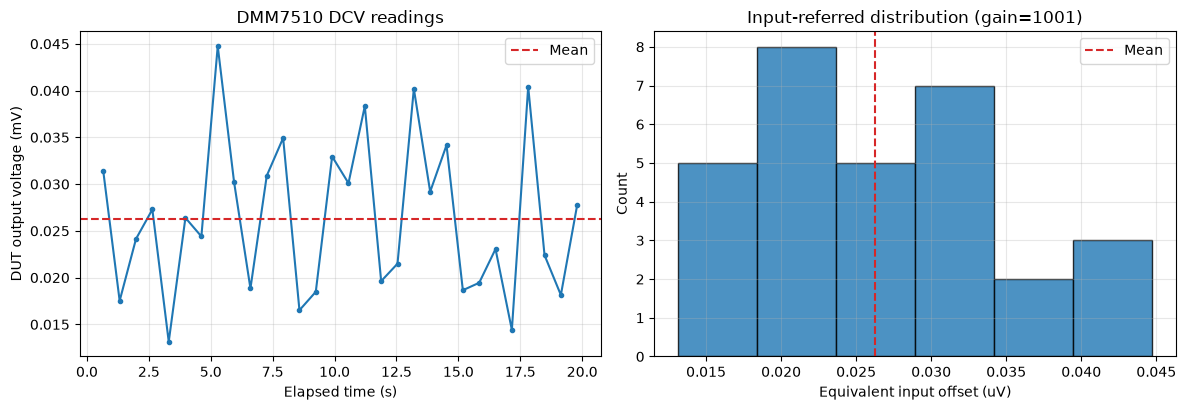

In [240]:
mean_v = float(np.mean(readings_v))
std_v = float(np.std(readings_v, ddof=1))
sem_v = std_v / np.sqrt(readings_v.size)
ci95_v = 1.96 * sem_v
equivalent_input_v = readings_v / CLOSED_LOOP_GAIN

print("\nMeasurement summary")
print(f"  Samples: {readings_v.size}")
print(f"  Duration: {elapsed_s[-1]:.2f} s")
print(f"  Output mean: {mean_v * 1e3:+.9f} mV")
print(f"  Output sample standard deviation: {std_v * 1e6:.3f} uV")
print(f"  Output standard error: {sem_v * 1e6:.3f} uV")
print(f"  Output mean descriptive 95% interval: +/- {ci95_v * 1e6:.3f} uV")
print(f"  Equivalent input offset (gain={CLOSED_LOOP_GAIN:g}): {mean_v / CLOSED_LOOP_GAIN * 1e6:+.6f} uV")
print(f"  Equivalent input standard error: {sem_v / CLOSED_LOOP_GAIN * 1e9:.3f} nV")

if np.max(np.abs(readings_v)) >= 0.09:
    print("WARNING: A reading is near the 100 mV range limit; inspect the DUT before trusting the result.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(elapsed_s, readings_v * 1e3, marker="o", markersize=3)
axes[0].axhline(mean_v * 1e3, color="tab:red", linestyle="--", label="Mean")
axes[0].set_xlabel("Elapsed time (s)")
axes[0].set_ylabel("DUT output voltage (mV)")
axes[0].set_title("DMM7510 DCV readings")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(equivalent_input_v * 1e6, bins="auto", edgecolor="black", alpha=0.8)
axes[1].axvline(mean_v / CLOSED_LOOP_GAIN * 1e6, color="tab:red", linestyle="--", label="Mean")
axes[1].set_xlabel("Equivalent input offset (uV)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Input-referred distribution (gain={CLOSED_LOOP_GAIN:g})")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

## Save individual readings (optional)

The CSV retains every reading rather than only the mean, which makes later drift and outlier checks possible.

In [241]:
if SAVE_CSV:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    csv_path = OUTPUT_DIR / f"DMM7510_DUT_offset_gain{CLOSED_LOOP_GAIN:g}_{timestamp}.csv"
    csv_data = np.column_stack((elapsed_s, readings_v, equivalent_input_v))
    header = (
        "elapsed_s,output_voltage_V,equivalent_input_offset_V\n"
        f"instrument={identity};resource={resource_name};terminals={actual_terminals};;\n"
        f"range_V={actual_range};nplc={actual_nplc};line_frequency_Hz={line_frequency};gain={CLOSED_LOOP_GAIN:g}"
    )
    np.savetxt(csv_path, csv_data, delimiter=",", header=header, comments="# ", fmt="%.12e")
    print(f"Saved: {csv_path.resolve()}")

Saved: C:\Users\jinge\Projects\Unicorn_Testbench\Unicorn_CSA_RevB-COB\data\demo\dmm7510_offset\DMM7510_DUT_offset_gain1001_20260903T163107Z.csv
